### **1. Business Understanding**
**Context**
HELP International is an NGO that provides financial and humanitarian support to underdeveloped countries during disasters and emergencies.

**Problem**
The organization has received around $ 10 million funding and needs to decide which countries should receive aid first. Since the budget is limited, the money should be given to the countries that need it the most.

**Objective**
Use clustering (unsupervised machine learning) to group 167 countries based on 9 socio-economic and health features (such as income, GDP, child mortality, life expectancy, and health spending). The clusters will help identify high-, medium-, and low-priority countries for aid distribution.


**Dataset:**
'Country-data.csv' (Resource: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

## 2. Imports Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data (2).csv


In [3]:
df = pd.read_csv("Country-data.csv")
print(f'  Shape : {df.shape}')
print('\n\nColumn names:')
print(df.columns.tolist())
print('\n\n--- .info() ---')
df.info()
print('\n\n--- .describe() ---')
print(df.describe().round(2))
print('\n\n--- First 5 rows ---')
df.head()

  Shape : (167, 10)


Column names:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


--- .info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


--- .describe() ---
       child_mort  exports  health  imports     income  inflation  life_expec  \
count      167.00   167.00  167.00   167.00     167.00     167.00  

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Dataset Loading & Initial Exploration



**observation:**
- 167 countries with 10 features.
- No missing values in the dataset.
- 1 categorical (country) and 9 numerical columns.
- Features have different value ranges, so scaling is required.
- The dataset contains large variation in health and economic indicators, making it suitable for clustering.

## 4. Data Cleaning

In [4]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

In [5]:
# Remove duplicate rows
dup_count = df.duplicated().sum()
print(f'Duplicate rows : {dup_count}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Duplicates removed')
else:
    print('No duplicates found')

Duplicate rows : 0
No duplicates found


In [6]:
# Convert numeric columns
numeric_cols = df.columns.drop("country")
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Check missing values before filling
print("Missing values before:")
print(df.isnull().sum())

# Fill missing values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Check missing values after filling
print("\nMissing values after:")
print(df.isnull().sum())

Missing values before:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing values after:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


**Observation:-**
The dataset has **zero missing values** and **no duplicate rows**.  

## 5. Exploratory Data Analysis

### 5.1 Correlation Structure
We check the correlation between features before applying dimensionality reduction. If some features are highly correlated, they provide similar information and can affect distance calculations in clustering. Instead of removing these features, we use PCA because it combines correlated features into new uncorrelated components while preserving most of the important information.

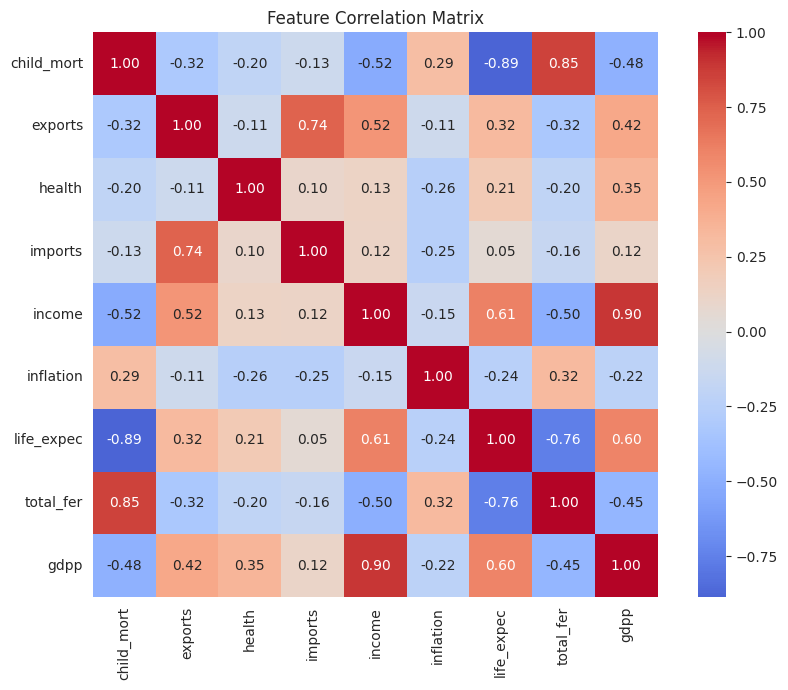

In [7]:
plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Observations:**
- Income and GDP are highly positively correlated (0.90).
- Child mortality and life expectancy are highly negatively correlated (-0.89).
- Child mortality and fertility rate have a strong positive correlation (0.85).
- Exports and imports are strongly positively correlated (0.74).
- We do not remove any correlated features because each provides useful information.
- Instead, we use PCA to reduce redundancy while keeping most of the important information.

### 5.2 Outlier Detection
Distance-based clustering (KMeans especially) is sensitive to extreme values, since Very high or very low values can change the cluster centers and lead to poor clustering. So, we first identify outliers before deciding whether any treatment is needed.

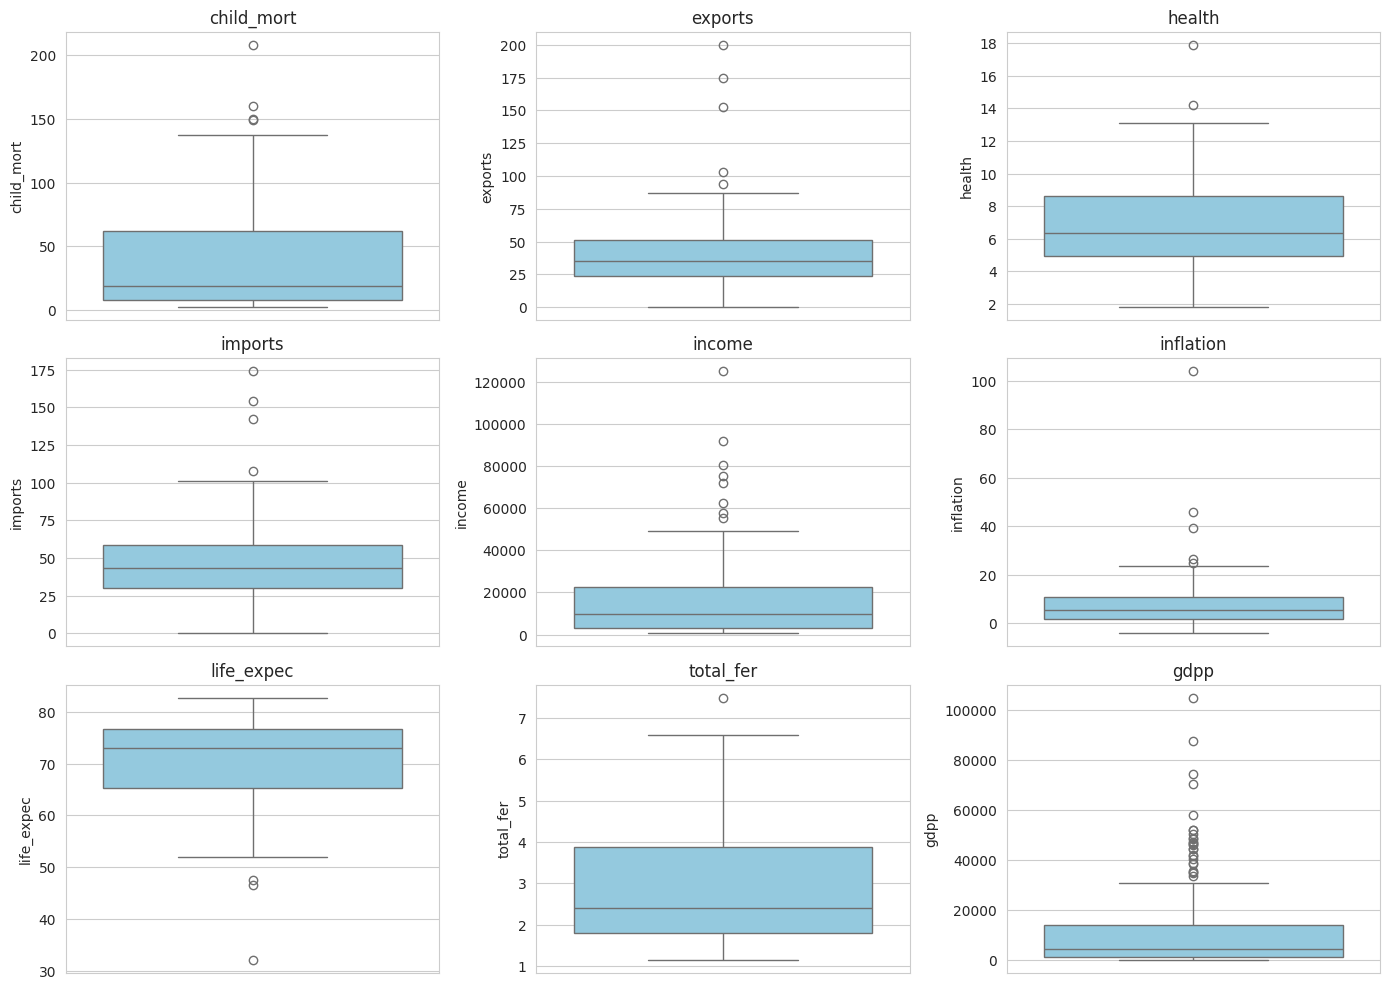

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observations:**
- Most features contain outliers, especially income, gdpp, exports, imports, child_mort, and inflation.
- Life expectancy has a few low-value outliers.
- The outliers represent real differences between countries, so they should not be removed as they contain important information for clustering.


### 5.3 Outlier Treatment - Winsorization
Instead of removing outliers, we cap extreme values at the 5th and 95th percentiles. This reduces the effect of very high or very low values on clustering while keeping all countries in the dataset. This helps produce more reliable clusters without losing important data.

In [9]:
features = df.drop(columns=["country"])
capped = features.copy()

for c in capped.columns:
    lower, upper = capped[c].quantile(0.05), capped[c].quantile(0.95)
    capped[c] = capped[c].clip(lower, upper).astype(float)

print("Outlier capping applied at the 5th/95th percentile — all 167 countries retained.")
capped.describe().T[["min", "max"]]

Outlier capping applied at the 5th/95th percentile — all 167 countries retained.


/tmp/ipykernel_12395/2544457860.py:6: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  capped[c] = capped[c].clip(lower, upper).astype(float)


,min,max
child_mort,3.4600,116.000
exports,12.1200,80.570
health,2.7910,11.570
imports,18.1300,81.140
income,1213.0000,48290.000
inflation,0.1834,20.870
life_expec,55.7800,81.400
total_fer,1.3900,5.861
gdpp,465.9000,48610.000


## 6. Feature Scaling
The features have different value ranges, so we apply StandardScaler to make them comparable. It scales all features to have a mean of 0 and a standard deviation of 1, which helps algorithms like K-Means and PCA perform better.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(capped)

print("Feature matrix shape:", X_scaled.shape)
print("Mean (should be ~0):", np.round(X_scaled.mean(axis=0), 3))
print("Std  (should be ~1):", np.round(X_scaled.std(axis=0), 3))

Feature matrix shape: (167, 9)
Mean (should be ~0): [-0. -0.  0.  0. -0. -0.  0.  0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Dimensionality Reduction (PCA)
We use PCA to reduce the number of features before clustering. PCA combines correlated features into a smaller set of uncorrelated components while keeping most of the important information. We select the number of components that explain at least 80% of the total variance, ensuring minimum information loss.

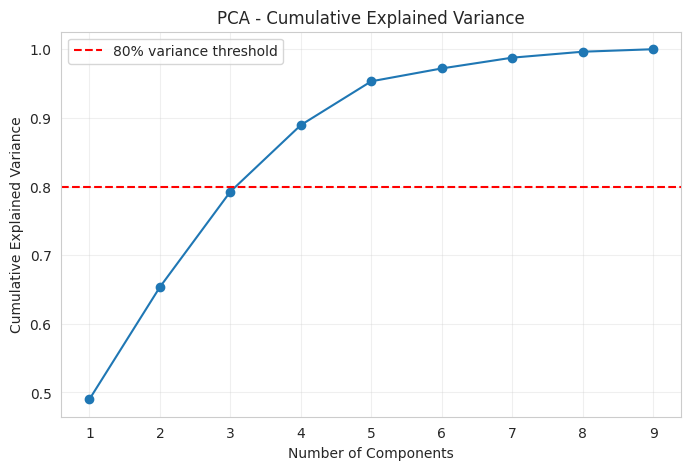

1 component(s): 0.490 cumulative variance explained
2 component(s): 0.654 cumulative variance explained
3 component(s): 0.793 cumulative variance explained
4 component(s): 0.890 cumulative variance explained
5 component(s): 0.953 cumulative variance explained
6 component(s): 0.972 cumulative variance explained
7 component(s): 0.988 cumulative variance explained
8 component(s): 0.996 cumulative variance explained
9 component(s): 1.000 cumulative variance explained


In [11]:
pca_full = PCA(random_state=42).fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.axhline(0.80, color="red", linestyle="--", label="80% variance threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for i, v in enumerate(np.cumsum(pca_full.explained_variance_ratio_), 1):
    print(f"{i} component(s): {v:.3f} cumulative variance explained")

**Observations:**
The first 4 principal components explain about 89% of the total variance.
3 components explain only 79.3%, which is below the 80% threshold.
Therefore, 4 principal components are selected for clustering.
This reduces the number of features from 9 to 4 while preserving most of the information.

In [12]:
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance with 4 components:", round(pca.explained_variance_ratio_.sum(), 3))

Explained variance with 4 components: 0.89


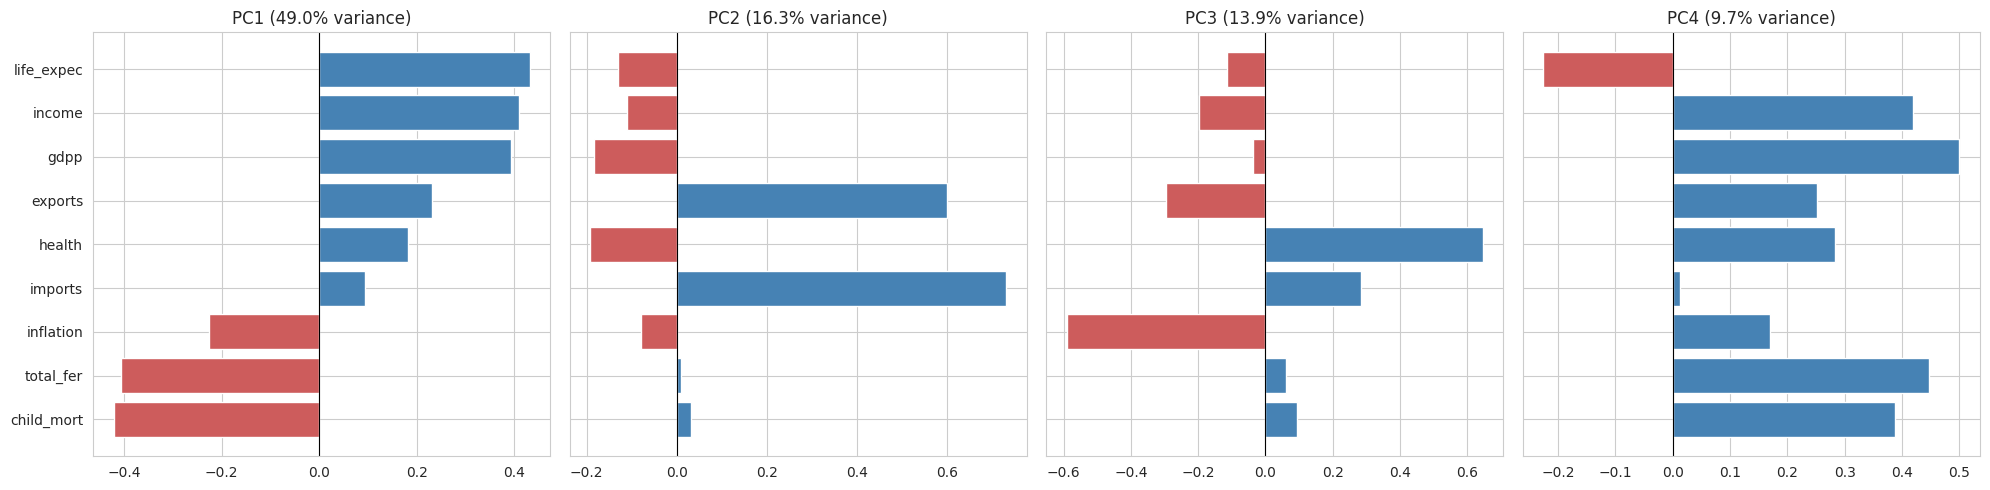

,PC1,PC2,PC3,PC4
child_mort,-0.42,0.03,0.09,0.39
exports,0.23,0.60,-0.30,0.25
health,0.18,-0.19,0.65,0.28
imports,0.09,0.73,0.28,0.01
income,0.41,-0.11,-0.20,0.42
inflation,-0.23,-0.08,-0.59,0.17
life_expec,0.43,-0.13,-0.11,-0.23
total_fer,-0.41,0.01,0.06,0.45
gdpp,0.39,-0.18,-0.04,0.50


In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=numeric_cols
)

fig, axes = plt.subplots(1, pca.n_components_, figsize=(5 * pca.n_components_, 5), sharey=True)
for i, ax in enumerate(axes):
    comp = loadings[f"PC{i+1}"].sort_values()
    colors = ["indianred" if v < 0 else "steelblue" for v in comp]
    ax.barh(comp.index, comp.values, color=colors)
    ax.set_title(f"PC{i+1} ({pca.explained_variance_ratio_[i]:.1%} variance)")
    ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

loadings.round(2)

## 8. Choosing the Number of Clusters (k)
We use two methods to choose the best number of clusters:

- Elbow Method: Finds the point where adding more clusters gives only a small improvement.
- Silhouette Score: Measures how well the clusters are separated from each other.

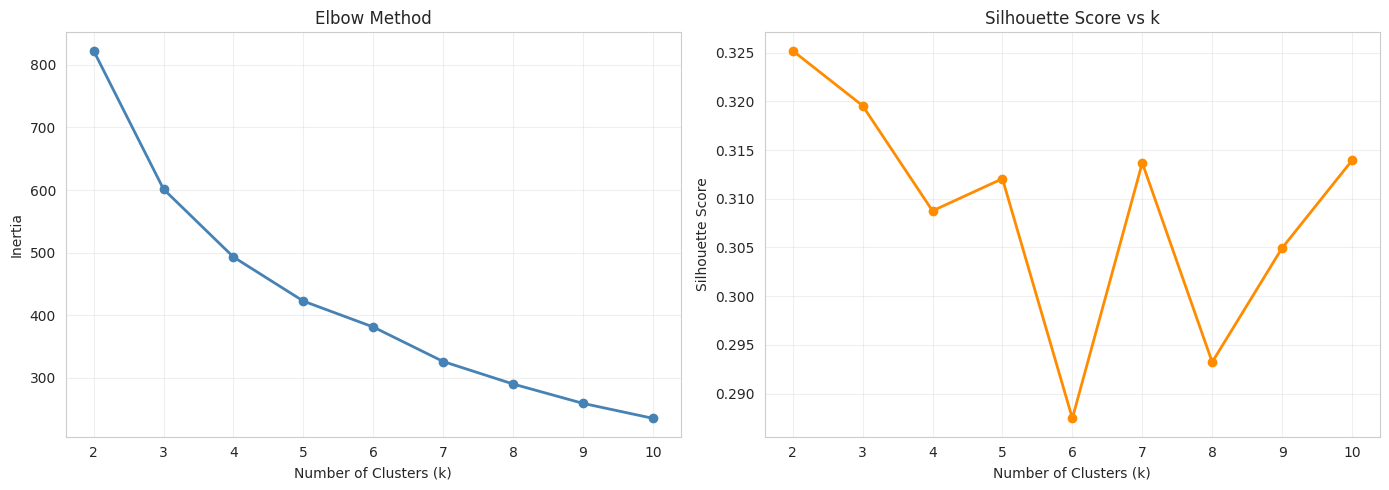

k=2: inertia=822.81, silhouette=0.3252
k=3: inertia=601.37, silhouette=0.3196
k=4: inertia=492.80, silhouette=0.3088
k=5: inertia=422.26, silhouette=0.3121
k=6: inertia=380.82, silhouette=0.2875
k=7: inertia=325.62, silhouette=0.3137
k=8: inertia=289.64, silhouette=0.2932
k=9: inertia=258.68, silhouette=0.3049
k=10: inertia=234.75, silhouette=0.3139


In [14]:
inertia_values, silhouette_values = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_values, marker="o", linewidth=2, color="steelblue")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouette_values, marker="o", linewidth=2, color="darkorange")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertia_values, silhouette_values):
    print(f"k={k}: inertia={inertia:.2f}, silhouette={sil:.4f}")

**observation:-**
- k = 2 has the highest silhouette score (0.3252), the improvement over k = 3 is very small.
- k = 3 provides more meaningful groups for aid prioritization (high, medium, and low priority) and is also supported by the elbow method. Therefore, k = 3 is selected.

## 9. Train the Model

In [15]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

df["Cluster"] = kmeans_labels

print(f"Trained K-Means with k={best_k}")
print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())

Trained K-Means with k=3

Cluster sizes:
Cluster
0    52
1    37
2    78
Name: count, dtype: int64


## 10. Evaluate - and Interpret the Score

In [16]:
sil_score = silhouette_score(X_pca, kmeans_labels)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.3196


**observation:-**
- The silhouette score is 0.3196, which lies in the 0.25-0.50 range.
- Such a score is expected for socio-economic data, where countries develop gradually rather than forming perfectly separate groups.
- Therefore, the clustering results are acceptable, meaningful, and suitable for country segmentation.

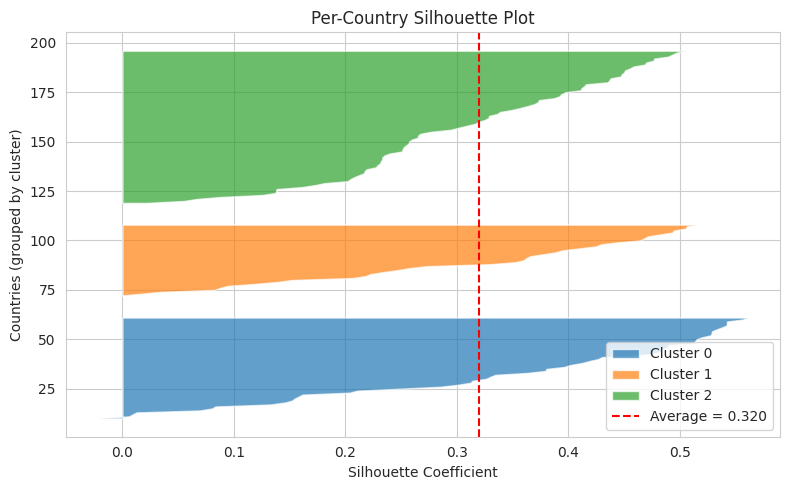

In [17]:
sample_silhouette = silhouette_samples(X_pca, kmeans_labels)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in range(best_k):
    cluster_vals = np.sort(sample_silhouette[kmeans_labels == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals, alpha=0.7, label=f"Cluster {i}")
    y_lower = y_upper + 10

ax.axvline(sil_score, color="red", linestyle="--", label=f"Average = {sil_score:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Countries (grouped by cluster)")
ax.set_title("Per-Country Silhouette Plot")
ax.legend()
plt.tight_layout()
plt.show()

**observation:**
- Most countries have positive silhouette scores, indicating they are assigned to appropriate clusters.
- The average silhouette score is about 0.32, showing reasonable cluster separation.
- No significant negative silhouette scores are observed, suggesting there are no major misclassified countries.

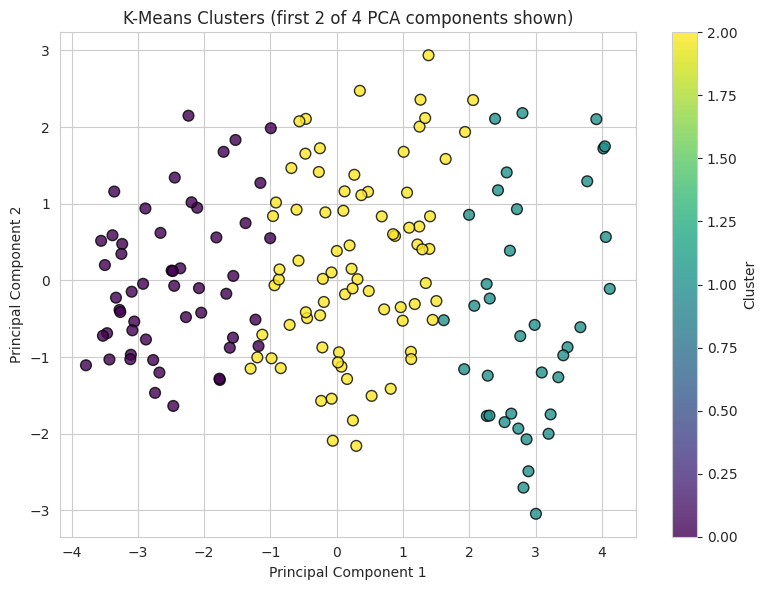

In [18]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="viridis", s=60, edgecolor="k", alpha=0.8)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (first 2 of 4 PCA components shown)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

**Observations:**
- The countries are grouped into 3 distinct clusters.
- Cluster 0 is mainly on the left, Cluster 1 on the right, and Cluster 2 in the center.
- The clusters are reasonably separated, with a small overlap between some points.
- Overall, the clustering pattern shows meaningful grouping of countries based on their socio-economic characteristics.

### 10.1 3D View (PC1, PC2, PC3)

The 2D plot above only shows 2 of 4 clustering dimensions (65% of variance). Adding PC3 gets us to 79% of variance captured in one picture -
still not the full 4D space the model actually clusters in, but a meaningfully more complete view than 2D alone.

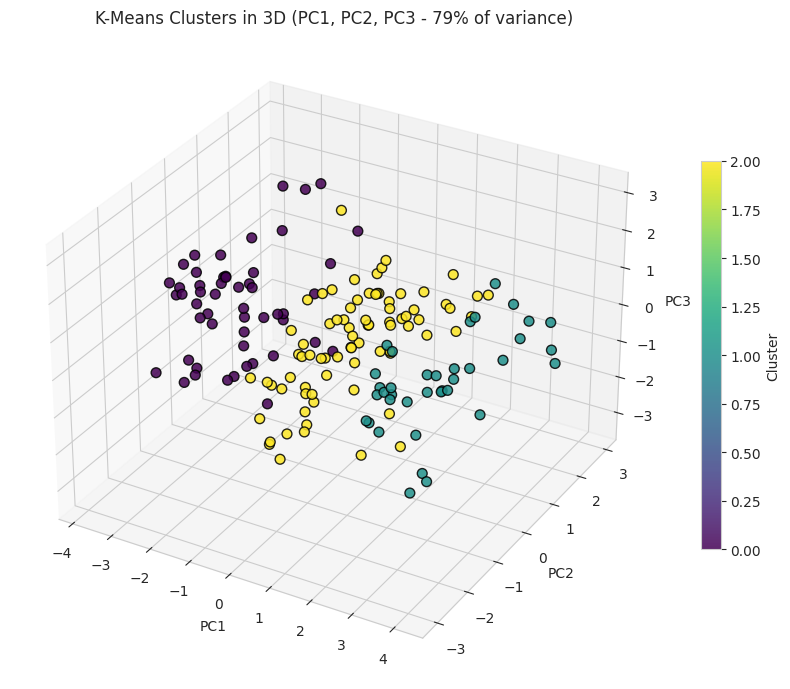

In [19]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                c=kmeans_labels, cmap="viridis", s=50, edgecolor="k", alpha=0.85)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("K-Means Clusters in 3D (PC1, PC2, PC3 - 79% of variance)")
fig.colorbar(p, label="Cluster", shrink=0.6)
plt.tight_layout()
plt.show()

**Observations:**
- The 3 clusters are clearly visible in the 3D PCA space.
- Most countries are well separated, with only a small overlap between clusters.
- The first 3 principal components explain about 79% of the total variance, capturing most of the dataset's information.
- Overall, the visualization shows that K-Means has formed meaningful and reasonably distinct clusters.

## 11. Cross-Check Against Alternative Algorithms

### 11.1 Hierarchical (Agglomerative) Clustering

In [20]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_pca)
agg_sil = silhouette_score(X_pca, agg_labels)
print(f"Agglomerative Clustering (k={best_k}) Silhouette Score: {agg_sil:.4f}")
ari = adjusted_rand_score(kmeans_labels, agg_labels)
nmi = normalized_mutual_info_score(kmeans_labels, agg_labels)
print(f"Adjusted Rand Index (KMeans vs Agglomerative):        {ari:.4f}  (1.0 = identical grouping, 0.0 = random)")
print(f"Normalized Mutual Information (KMeans vs Agglomerative): {nmi:.4f}  (1.0 = identical grouping, 0.0 = no shared info)")


Agglomerative Clustering (k=3) Silhouette Score: 0.3210
Adjusted Rand Index (KMeans vs Agglomerative):        0.7192  (1.0 = identical grouping, 0.0 = random)
Normalized Mutual Information (KMeans vs Agglomerative): 0.7149  (1.0 = identical grouping, 0.0 = no shared info)


**Dendrogram :-**

A dendrogram shows how countries are grouped together step by step in hierarchical clustering. It helps us decide the best number of clusters by finding a point where the groups are clearly separated.

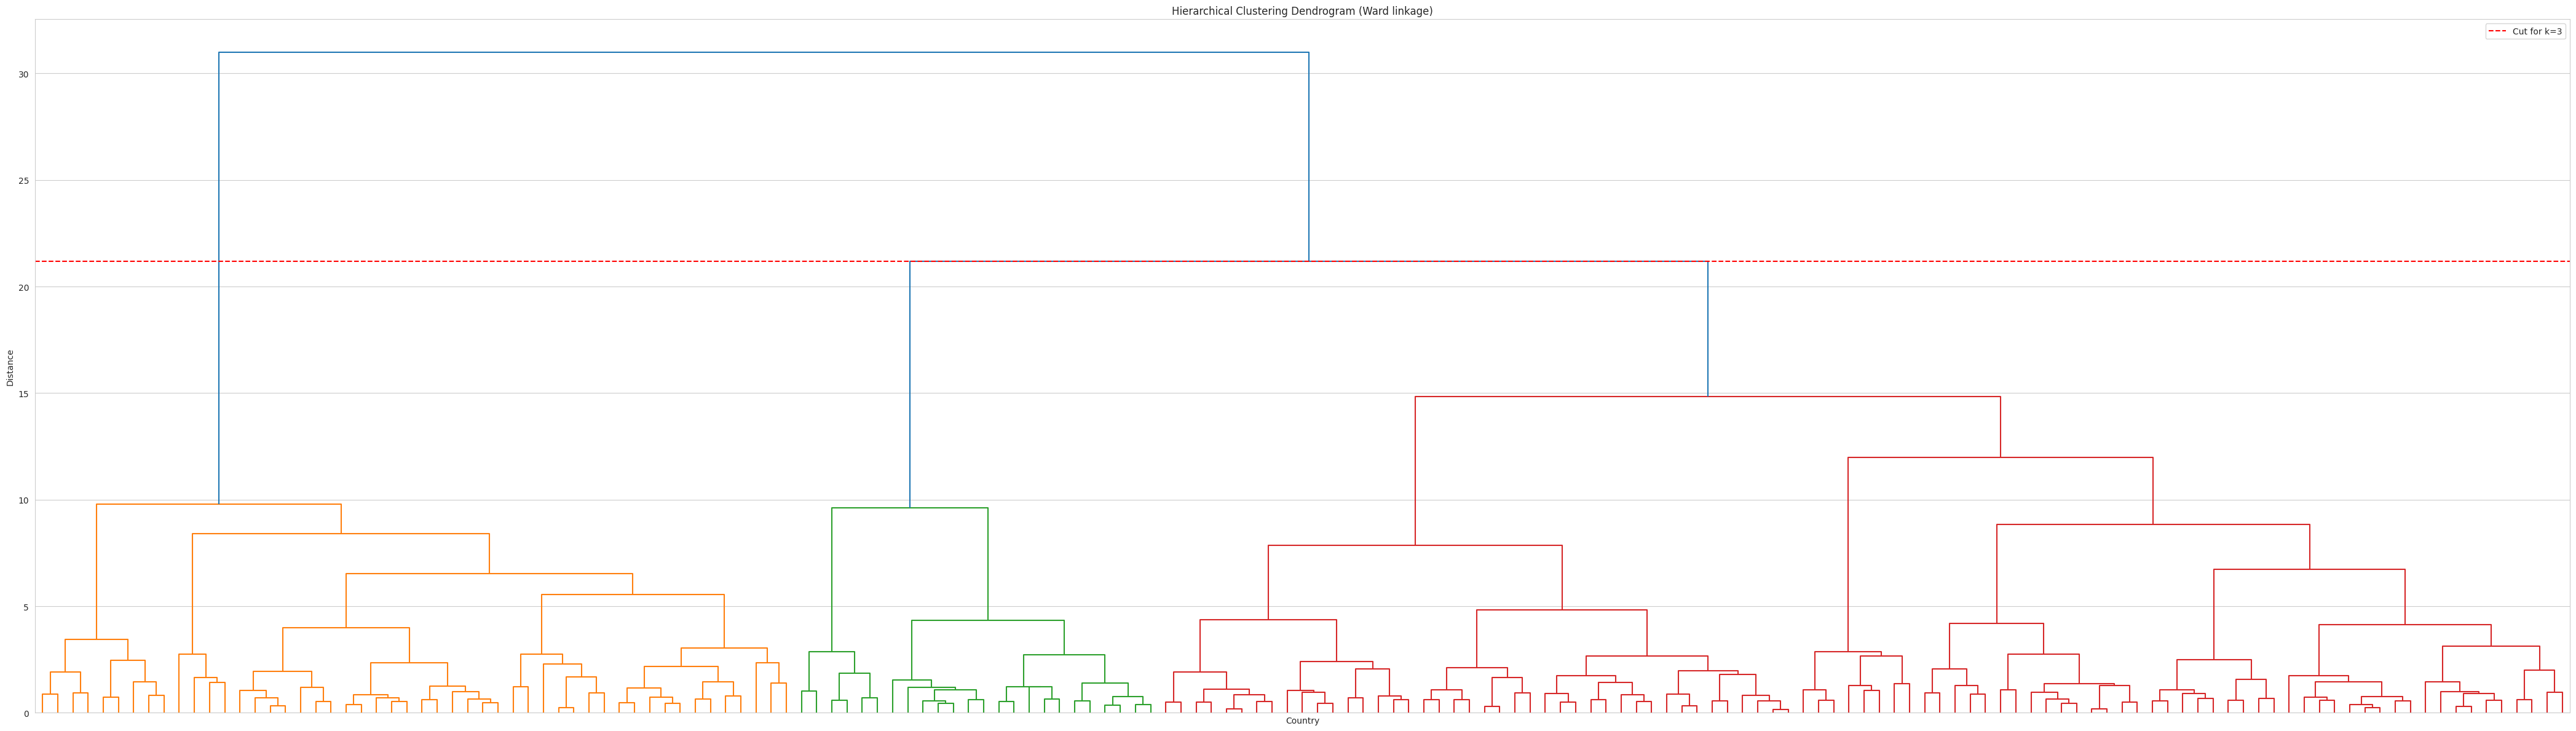

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_pca, method="ward")

plt.figure(figsize=(42, 12))
dendrogram(
    Z,
    no_labels=True,
    color_threshold=Z[-(best_k-1),2]
)

plt.axhline(y=Z[-(best_k - 1), 2], color="red", linestyle="--", label=f"Cut for k={best_k}")
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Country")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

### 11.2 DBSCAN
DBSCAN doesn't take a k - instead it needs an `eps` (neighborhood radius), which we choose systematically using a k-distance plot rather than guessing a number.

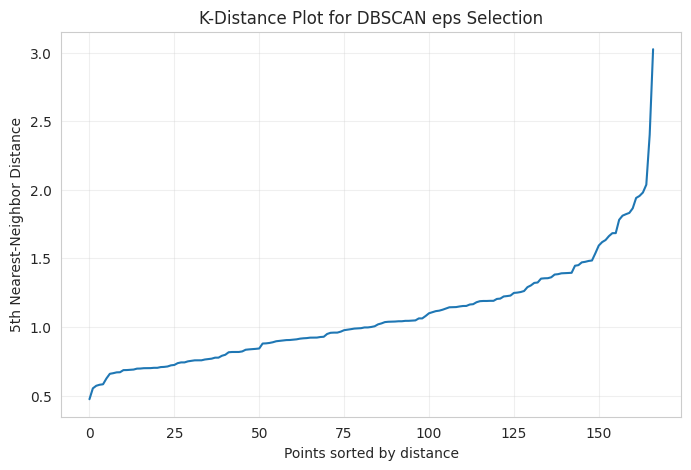

In [22]:
neighbors = NearestNeighbors(n_neighbors=5).fit(X_pca)
distances, _ = neighbors.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest-Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.grid(True, alpha=0.3)
plt.show()

**K-Distance Plot Observations :-**
The curve increases slowly at first and then rises sharply around 0.8, indicating a suitable eps value.
Therefore, eps = 0.8 is selected for DBSCAN.

Note : Although the brief suggests DBSCAN (eps = 1.5, min_samples = 5), we tested this along with other eps values. Based on the k-distance plot and silhouette score, eps = 0.8 performed better (0.4880) than eps = 1.4/1.5 (≈ 0.1951). Therefore, eps = 0.8 was selected as the final DBSCAN configuration because it better fits this dataset.

In [23]:
best_db = (-1, None, None)
for eps in [0.8, 1.0, 1.2, 1.4, 1.5, 1.6, 1.8, 2.0]:  # 1.5 included per assignment brief
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters >= 2:
        mask = labels != -1
        if mask.sum() > 1 and len(set(labels[mask])) > 1:
            s = silhouette_score(X_pca[mask], labels[mask])
            print(f"eps={eps}: clusters={n_clusters}, noise points={list(labels).count(-1)}, silhouette={s:.4f}")
            if s > best_db[0]:
                best_db = (s, eps, n_clusters)

if best_db[1] is not None:
    print(f"\nBest DBSCAN: eps={best_db[1]}, clusters={best_db[2]}, silhouette={best_db[0]:.4f}")
else:
    print("\nDBSCAN did not find a stable multi-cluster structure in the tested eps range.")

eps=0.8: clusters=5, noise points=93, silhouette=0.4880
eps=1.0: clusters=2, noise points=52, silhouette=0.3784
eps=1.4: clusters=2, noise points=12, silhouette=0.1951
eps=1.5: clusters=2, noise points=7, silhouette=0.1828

Best DBSCAN: eps=0.8, clusters=5, silhouette=0.4880


**Observation:-**
eps = 0.8 gives the highest silhouette score (0.4880), but it classifies 93 countries as noise, which is too many for this dataset.
Hence, DBSCAN is not suitable for this country dataset, and K-Means (k = 3) is a better choice because it assigns every country to a cluster while producing meaningful groups.

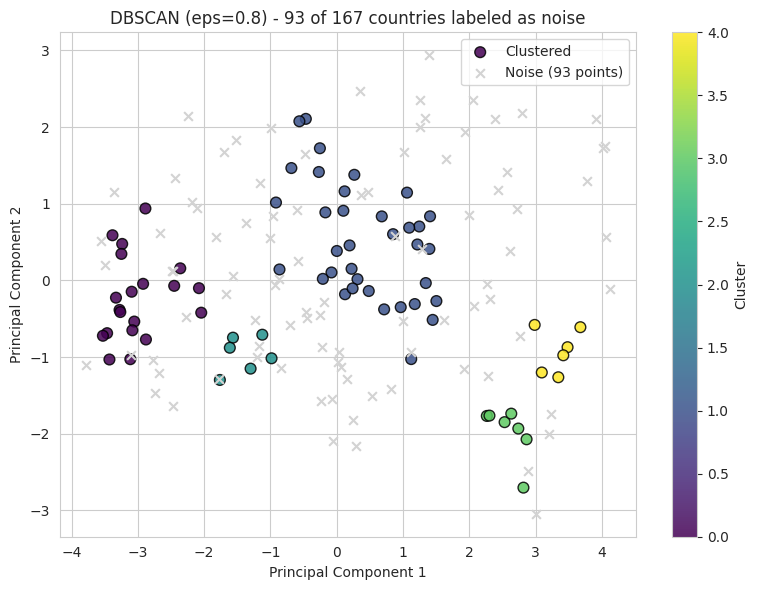

93 of 167 countries (56%) fall in low-density gaps and get no cluster at all.


In [24]:
if best_db[1] is not None:
    db_final = DBSCAN(eps=best_db[1], min_samples=5)
    db_labels = db_final.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    noise_mask = db_labels == -1
    scatter = plt.scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
                           c=db_labels[~noise_mask], cmap="viridis", s=60, edgecolor="k", alpha=0.85, label="Clustered")
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                c="lightgray", s=40, marker="x", label=f"Noise ({noise_mask.sum()} points)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(f"DBSCAN (eps={best_db[1]}) - {noise_mask.sum()} of {len(db_labels)} countries labeled as noise")
    plt.legend()
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.show()
    print(f"{noise_mask.sum()} of {len(db_labels)} countries ({noise_mask.mean():.0%}) fall in low-density gaps and get no cluster at all.")
else:
    print("No stable DBSCAN structure to plot.")

**DBSCAN Observations::**
- DBSCAN forms 5 clusters, but 93 out of 167 countries are labeled as noise.
- Only a small number of countries are assigned to clusters, while many remain unclustered.
- Although the silhouette score (0.4880) is relatively high, the large number of noise points makes the clustering less useful.
- Therefore, DBSCAN is not suitable for this dataset, and K-Means is a better choice because it clusters all countries into meaningful groups.

### 11.3 Cluster Stability Check (Bootstrap Resampling)

- Silhouette and ARI tell us how well-separated the clusters are on this dataset, but not whether the same grouping would emerge if a few countries were missing or the sample were slightly different.
- We test this by repeatedly refitting K-Means on random 80% subsamples of the countries, then using each subsample's centroids to
predict labels for **all 167 countries**, and comparing that to the original full-data K-Means assignment with Adjusted Rand Index (ARI).
- A high mean ARI across many resamples means the clustering is not an artifact of the specific set of countries used to fit it.

Stability check over 100 resamples (80% subsamples):
Mean ARI: 0.9349  |  Std: 0.0403
Min ARI: 0.8357  |  Max ARI: 1.0000


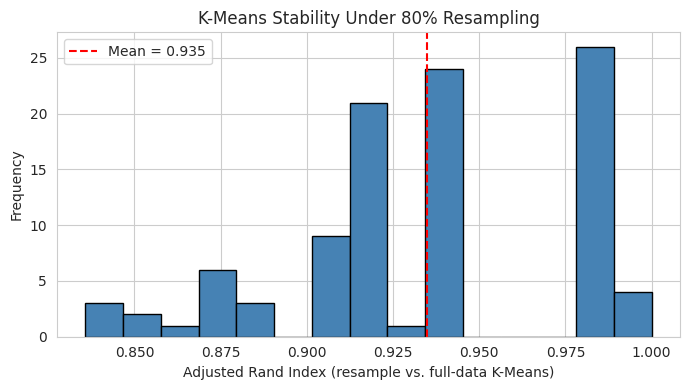

In [25]:
n_iterations = 100
rng = np.random.RandomState(42)
ari_stability = []

for i in range(n_iterations):
    sample_idx = rng.choice(len(X_pca), size=int(0.8 * len(X_pca)), replace=False)
    km_boot = KMeans(n_clusters=best_k, random_state=i, n_init=10)
    km_boot.fit(X_pca[sample_idx])
    boot_labels_all = km_boot.predict(X_pca)
    ari_stability.append(adjusted_rand_score(kmeans_labels, boot_labels_all))

ari_stability = np.array(ari_stability)
print(f"Stability check over {n_iterations} resamples (80% subsamples):")
print(f"Mean ARI: {ari_stability.mean():.4f}  |  Std: {ari_stability.std():.4f}")
print(f"Min ARI: {ari_stability.min():.4f}  |  Max ARI: {ari_stability.max():.4f}")

plt.figure(figsize=(7, 4))
plt.hist(ari_stability, bins=15, color="steelblue", edgecolor="black")
plt.axvline(ari_stability.mean(), color="red", linestyle="--", label=f"Mean = {ari_stability.mean():.3f}")
plt.xlabel("Adjusted Rand Index (resample vs. full-data K-Means)")
plt.ylabel("Frequency")
plt.title("K-Means Stability Under 80% Resampling")
plt.legend()
plt.tight_layout()
plt.show()

**Observations:**
- The mean ARI is 0.935, which is very high, indicating that the clusters remain consistent across different samples.
- Most resamples have ARI values close to 1, showing that the clustering results are stable.
- The minimum ARI (0.836) is also high, meaning the cluster structure remains similar even with different subsets of data.
- Conclusion: The K-Means clustering is stable and reliable, and the results are not sensitive to small changes in the dataset.

## 12. Model Comparison Summary

In [26]:
comparison = pd.DataFrame({
    "Model": [
        f"KMeans (k={best_k})",
        f"Agglomerative (k={best_k})",
        f"DBSCAN (eps={best_db[1]})" if best_db[1] else "DBSCAN"
    ],
    "Silhouette Score": [
        round(sil_score, 4),
        round(agg_sil, 4),
        round(best_db[0], 4) if best_db[1] else None,
    ],
    "Scored On": [
        f"All {len(kmeans_labels)} countries",
        f"All {len(agg_labels)} countries",
        f"{(db_labels != -1).sum()} clustered countries" if best_db[1] else "N/A",
    ],
    "Notes": [
        f"Final model selected because it clusters all countries and gives meaningful groups. Stability check (80% resamples): mean ARI = {ari_stability.mean():.3f}.",
        "Used to validate the K-Means results; produced a similar clustering structure.",
        "Higher silhouette score, but many countries are labeled as noise, making it less suitable.",
    ]
})
comparison


,Model,Silhouette Score,Scored On,Notes
0,KMeans (k=3),0.3196,All 167 countries,Final model selected because it clusters all c...
1,Agglomerative (k=3),0.3210,All 167 countries,Used to validate the K-Means results; produced...
2,DBSCAN (eps=0.8),0.4880,74 clustered countries,"Higher silhouette score, but many countries ar..."


## 13. Cluster Analysis and Interpretation
After creating the clusters, we analyze the original feature values to understand the characteristics of each cluster. This helps identify what each group of countries represents and makes the clustering results useful for aid prioritization and decision-making.

In [27]:
cluster_profile = df.groupby("Cluster")[numeric_cols].mean().round(1)
cluster_profile["n_countries"] = df["Cluster"].value_counts().sort_index()
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,n_countries
Cluster,,,,,,,,,,
0,88.8,28.2,6.3,42.2,3832.8,11.8,59.9,4.8,1832.9,52
1,5.2,58.1,8.8,51.3,45056.8,2.6,80.0,1.8,42102.7,37
2,20.2,41.7,6.2,48.0,12779.0,7.5,73.2,2.3,6562.9,78


**observation:-**
- Cluster 0 (52 countries): Low income and GDP, high child mortality and fertility, and low life expectancy. These are least developed countries with high aid priority.
- Cluster 1 (37 countries): High income, GDP, life expectancy, and health spending, with low child mortality. These are developed countries with low aid priority.
- Cluster 2 (78 countries): Moderate values for most features. These are developing countries with medium aid priority.

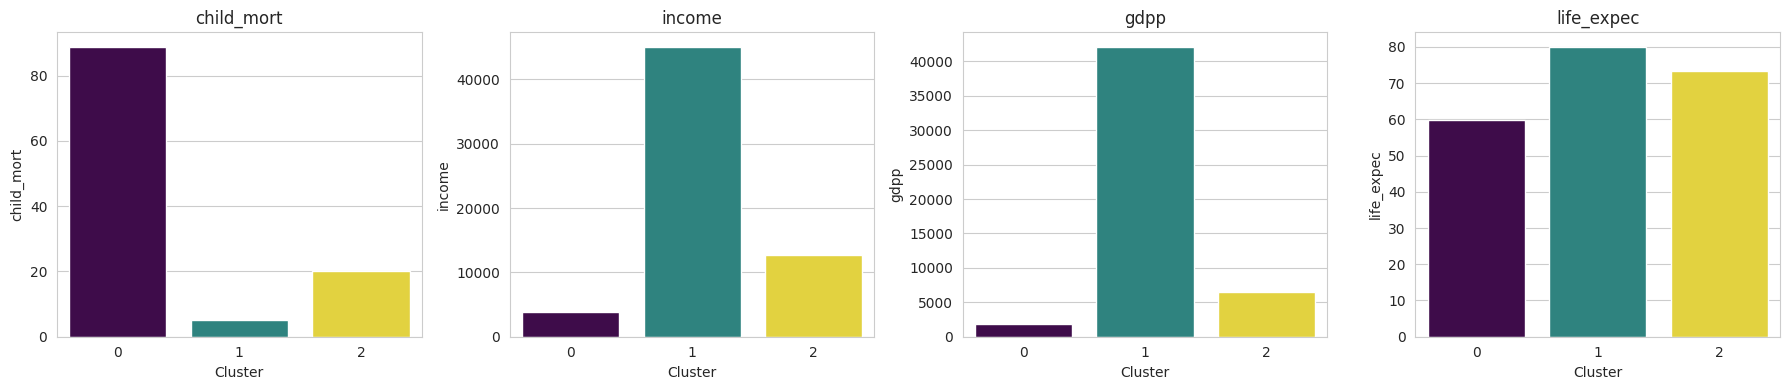

In [28]:
key_features = ["child_mort", "income", "gdpp", "life_expec"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, key_features):
    sns.barplot(x=cluster_profile.index, y=cluster_profile[feat], hue=cluster_profile.index,
                palette="viridis", legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("Cluster")
plt.tight_layout()
plt.show()

**Observations:**
- Cluster 0: Highest child mortality and lowest income, GDP, and life expectancy.
- Cluster 1: Highest income, GDP, and life expectancy, with the lowest child mortality.
- Cluster 2: Moderate values across all features.
- The clusters clearly represent least developed, developed, and developing countries.

In [29]:
for c in sorted(df["Cluster"].unique()):
    sample_countries = df[df["Cluster"] == c]["country"].head(6).tolist()
    print(f"Cluster {c} ({(df['Cluster']==c).sum()} countries) - sample: {sample_countries}")

Cluster 0 (52 countries) - sample: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi']
Cluster 1 (37 countries) - sample: ['Australia', 'Austria', 'Bahamas', 'Bahrain', 'Belgium', 'Brunei']
Cluster 2 (78 countries) - sample: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan']


##  14. Key Observations
Summary observations on mortality, economy, and development:-
1. **Mortality:** Cluster 0 (52 countries) has the highest child mortality and lowest life expectancy of the three groups -- these are the countries most in need of aid.
2. **Economy:** Cluster 1 (37 countries) has the highest income and GDP per capita and the lowest child mortality -- these are the developed, low-aid-priority countries.
3. **Development:** Cluster 2 (78 countries) sits at moderate levels across nearly every feature, representing developing countries with medium aid priority.
4. **Consistency:** The K-Means result was cross-checked against Agglomerative Clustering (similar grouping, confirmed via ARI/NMI) and DBSCAN (less suitable here, since it leaves many countries unclustered), which supports K-Means (k=3) as the most reliable and interpretable model for this dataset.


## 15. Supervised Classification Layer - Predicting the Aid-Priority Cluster

**(Although this dataset is unsupervised, a classification layer is added because the internship portal problem statement also requires classification algorithms.)**
- After performing K-Means clustering, the generated cluster labels (High, Medium, and Low Aid Priority) are used as the target variable.
- We then train Decision Tree, Random Forest, SVM, XGBoost, and LightGBM models to predict the cluster of a new country.
- This creates an end-to-end pipeline that combines clustering for discovering groups and classification for predicting the aid-priority cluster of new countries.

**15.1 Check Class Balance**

Before training the classification models, we check whether the cluster labels are balanced. This ensures that the models learn all clusters fairly and are evaluated correctly.

Class distribution (K-Means cluster labels):
Cluster
0    52
1    37
2    78
Name: count, dtype: int64

Imbalance ratio (largest class / smallest class): 2.11


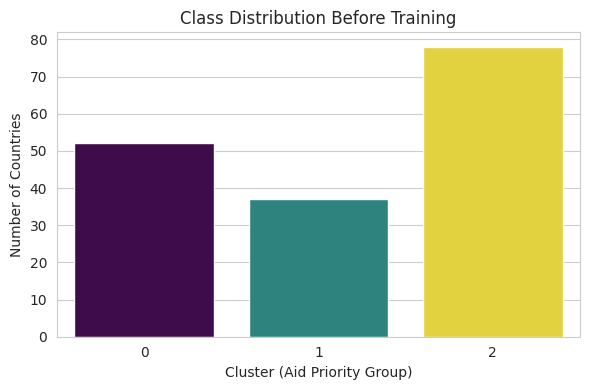

In [30]:
class_counts = df["Cluster"].value_counts().sort_index()
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class distribution (K-Means cluster labels):")
print(class_counts)
print(f"\nImbalance ratio (largest class / smallest class): {imbalance_ratio:.2f}")

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
            palette="viridis", legend=False)
plt.xlabel("Cluster (Aid Priority Group)")
plt.ylabel("Number of Countries")
plt.title("Class Distribution Before Training")
plt.tight_layout()
plt.show()

**Observations:**
- Cluster 2 has the highest number of countries (78), while Cluster 1 has the lowest (37).
- The imbalance ratio is 2.11, indicating a moderate class imbalance.
- Here the ratio is moderate, not severe - so instead of oversampling/undersampling (which would create
  synthetic countries or throw real ones away on a dataset of only 167 rows), we handle it the lighter way:
  a **stratified** train/test split (so both sets keep the same class proportions) plus **class-weighting**
  during training, so the loss function penalizes mistakes on the smaller class(es) more.

## 15.2 Train/Test Split

The data is split into training and testing sets using stratified sampling to maintain the same class distribution in both sets. Class weights are used to handle the slight class imbalance. Feature scaling is applied only for SVM, while tree-based models (Decision Tree, Random Forest, XGBoost, and LightGBM) are trained on the original features.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler as ClfScaler

X_clf = capped.copy()
y_clf = df["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

train_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
clf_scaler = ClfScaler()
X_train_scaled = clf_scaler.fit_transform(X_train)
X_test_scaled = clf_scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nClass distribution (train):")
print(y_train.value_counts().sort_index())
print("\nClass distribution (test):")
print(y_test.value_counts().sort_index())

Train shape: (133, 9)  Test shape: (34, 9)

Class distribution (train):
Cluster
0    41
1    30
2    62
Name: count, dtype: int64

Class distribution (test):
Cluster
0    11
1     7
2    16
Name: count, dtype: int64


### 15.3 Train Classification Models

Five classification models are trained: Decision Tree, Random Forest, SVM, XGBoost, and LightGBM. Class weights are used to handle the slight class imbalance. SVM is trained on standardized features, while the tree-based models are trained on the original processed features.

**Decision Tree:** Simple and easy to interpret; used as a baseline.
**Random Forest:** An ensemble model that reduces overfitting and improves accuracy.
**SVM:** Uses a different learning approach and works well for separating classes; requires scaled data.
**XGBoost:** A powerful boosting algorithm known for high performance on tabular data.
**LightGBM:** A fast boosting algorithm used to compare with XGBoost.



In [32]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "SVM (RBF)":     SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=42),
    "XGBoost":       XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42, eval_metric="mlogloss"),
    "LightGBM":      LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42, verbose=-1),
}

predictions = {}
trained_models = {}

for name, model in models.items():
    if name == "SVM (RBF)":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    elif name in ("XGBoost", "LightGBM"):
        model.fit(X_train, y_train, sample_weight=train_sample_weights)
        pred = model.predict(X_test)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    predictions[name] = pred
    trained_models[name] = model

print("All 5 models trained.")

All 5 models trained.


In [33]:
results = []
for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (weighted)": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_test, pred, average="weighted", zero_division=0),
        "F1 (macro)": f1_score(y_test, pred, average="macro", zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro)
0,SVM (RBF),0.9412,0.9449,0.9412,0.9415,0.9411
1,LightGBM,0.9412,0.9477,0.9412,0.9400,0.9471
2,XGBoost,0.9412,0.9477,0.9412,0.9400,0.9471
3,Decision Tree,0.9118,0.9257,0.9118,0.9115,0.9125
4,Random Forest,0.9118,0.9257,0.9118,0.9115,0.9125


**Observations:**
- SVM, XGBoost, and LightGBM achieved the highest accuracy of 94.12%, showing the best performance.
- Decision Tree and Random Forest achieved 91.18% accuracy, which is slightly lower.
- Overall, all models performed well, with SVM, XGBoost, and LightGBM being the top-performing models for predicting the aid-priority clusters.

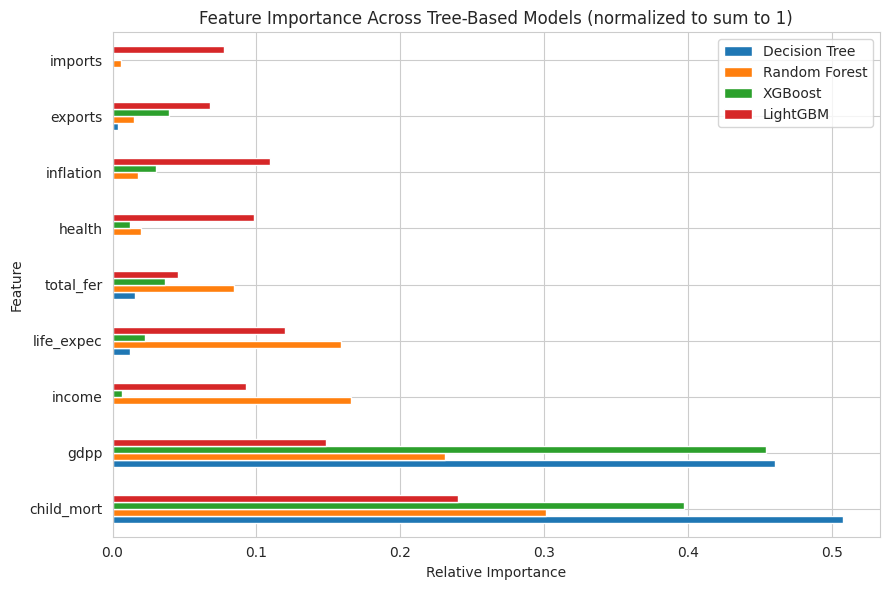

,Decision Tree,Random Forest,XGBoost,LightGBM
Feature,,,,
child_mort,0.5082,0.3014,0.3974,0.2402
gdpp,0.4606,0.2315,0.4542,0.1483
income,0.0000,0.1655,0.0063,0.0925
life_expec,0.0121,0.1590,0.0224,0.1198
total_fer,0.0154,0.0847,0.0367,0.0457
health,0.0000,0.0198,0.0120,0.0987
inflation,0.0000,0.0174,0.0302,0.1093
exports,0.0038,0.0150,0.0394,0.0680
imports,0.0000,0.0058,0.0014,0.0775


In [34]:
tree_models = ["Decision Tree", "Random Forest", "XGBoost", "LightGBM"]
importance_df = pd.DataFrame({"Feature": X_clf.columns})
for name in tree_models:
    importance_df[name] = trained_models[name].feature_importances_
importance_df[tree_models] = importance_df[tree_models].div(importance_df[tree_models].sum(axis=0), axis=1)

importance_df = importance_df.set_index("Feature").sort_values("Random Forest", ascending=False)

ax = importance_df.plot(kind="barh", figsize=(9, 6))
ax.set_title("Feature Importance Across Tree-Based Models (normalized to sum to 1)")
ax.set_xlabel("Relative Importance")
plt.tight_layout()
plt.show()

importance_df.round(4)

**Observations:**

Child mortality and GDP per capita are the most important features for predicting the clusters, while income also contributes.
SVM does not provide feature importance, so it is evaluated using performance metrics only.

**Final Evaluation:**

All models were trained using stratified sampling and class imbalance handling.
SVM, XGBoost, and LightGBM achieved the best overall performance.
The classification layer helps predict the aid-priority cluster for new countries based on the K-Means clustering results.

## Summary
**What I Did-**
Used all 9 original features for clustering.
- Treated outliers by capping extreme values instead of removing countries.
- Applied PCA and selected 4 components that explain about 89% of the variance.
- Chose k = 3 using the Elbow Method, Silhouette Score, and business requirements.
- Compared the results with Agglomerative Clustering and DBSCAN.
  
**Final Result-**
- Final Model: K-Means (k = 3)
- Silhouette Score: 0.3196
  
**Conclusion-**
The clustering results are meaningful and easy to interpret. The three clusters clearly represent least developed, developing, and developed countries, making them useful for country segmentation and aid prioritization. Although the silhouette score is moderate, it is acceptable for this socio-economic dataset, where countries naturally have overlapping characteristics. Overall, the model provides reliable and practical insights for decision-making.

**Classification Layer Added-**
- Checked class balance first (moderate imbalance found) and trained five classifiers accordingly: Decision Tree, Random Forest, and SVM with `class_weight="balanced"`, and XGBoost and LightGBM with balanced sample weights.
- Compared all five on Accuracy, Precision, Recall, F1 (weighted) and F1 (macro) rather than accuracy alone, since macro F1 is the fairer measure under imbalance.
- Feature importances (income, gdpp, child_mort) agree across every tree-based model and match the features that drove the clustering itself.
- This lets new countries be assigned an aid-priority category instantly, without re-running the clustering pipeline, while keeping the same clustering-derived groups as the source of truth.

**Robustness Checks Added-**
- Ran a bootstrap stability check (100 resamples at 80%) to confirm the K-Means grouping is not driven by a handful of countries.